## Phase 2: Categorical EDA and One-Hot Encoding

In this notebook, we use the cleaned dataset from Phase 1. We will look at the categorical columns, explore them, and turn them into numbers so they can be used in machine learning models.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# This makes the plots look cleaner
sns.set(style="whitegrid")

# Load the cleaned "gold" dataset created in Phase 1
df = pd.read_csv("gold_housing_data.csv")

# Show the first 5 rows to quickly check the data loaded correctly
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [3]:
# Basic dataset check. This helps us understand the size of the dataset and what columns are inside it.

print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

# Show data types and whether any columns still have missing values
df.info()

Shape of dataset: (1460, 77)

Column names:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 

In [4]:
# Identify categorical columns. Categorical columns are text-based columns, for example: Neighborhood, HouseStyle, KitchenQual, GarageType, SaleCondition, etc.
# These columns need to be converted into numbers before modeling.

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Number of categorical columns:", len(categorical_cols))
print("\nCategorical columns:")
print(categorical_cols)

Number of categorical columns: 39

Categorical columns:
['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']


In [5]:
# Check missing values in categorical columns. Even though Phase 1 cleaned the dataset, we check again to make sure there are no missing values left in the categorical columns.

missing_categorical = df[categorical_cols].isnull().sum()
missing_categorical = missing_categorical[missing_categorical > 0].sort_values(ascending=False)

print("Missing values in categorical columns:")
print(missing_categorical)

Missing values in categorical columns:
MasVnrType      872
FireplaceQu     690
GarageType       81
GarageFinish     81
GarageQual       81
GarageCond       81
BsmtExposure     38
BsmtFinType2     38
BsmtQual         37
BsmtCond         37
BsmtFinType1     37
dtype: int64


In [6]:
# Check how many unique categories each categorical column has. This is useful because some columns have only a few categories, while others may have many categories.

categorical_cardinality = df[categorical_cols].nunique().sort_values(ascending=False)

print("Number of unique categories in each categorical column:")
print(categorical_cardinality)

Number of unique categories in each categorical column:
Neighborhood     25
Exterior2nd      16
Exterior1st      15
SaleType          9
Condition1        9
Condition2        8
HouseStyle        8
RoofMatl          8
Functional        7
Foundation        6
GarageType        6
Heating           6
BsmtFinType2      6
BsmtFinType1      6
SaleCondition     6
RoofStyle         6
BldgType          5
GarageCond        5
GarageQual        5
FireplaceQu       5
Electrical        5
HeatingQC         5
LotConfig         5
MSZoning          5
ExterCond         5
BsmtExposure      4
BsmtCond          4
BsmtQual          4
KitchenQual       4
LandContour       4
ExterQual         4
LotShape          4
LandSlope         3
MasVnrType        3
GarageFinish      3
PavedDrive        3
Utilities         2
Street            2
CentralAir        2
dtype: int64


In [7]:
# Look at the category counts for each categorical column. This shows how often each category appears.

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- MSZoning ---
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

--- Street ---
Street
Pave    1454
Grvl       6
Name: count, dtype: int64

--- LotShape ---
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

--- LandContour ---
LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64

--- Utilities ---
Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

--- LotConfig ---
LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64

--- LandSlope ---
LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64

--- Neighborhood ---
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
Cl

In [8]:
# Compare each category with SalePrice. This helps us see whether some categories are linked with higher or lower house prices. For each categorical column, we calculate:
# count  = how many houses are in that category
# mean   = average SalePrice
# median = middle SalePrice

for col in categorical_cols:
    print(f"\n--- Average SalePrice by {col} ---")
    display(
        df.groupby(col)["SalePrice"]
        .agg(["count", "mean", "median"])
        .sort_values("mean", ascending=False)
    )


--- Average SalePrice by MSZoning ---


,count,mean,median
MSZoning,,,
FV,65,214014.061538,205950.0
RL,1151,191004.994787,174000.0
RH,16,131558.375000,136500.0
RM,218,126316.830275,120500.0
C (all),10,74528.000000,74700.0



--- Average SalePrice by Street ---


,count,mean,median
Street,,,
Pave,1454,181130.538514,163000.0
Grvl,6,130190.500000,114250.0



--- Average SalePrice by LotShape ---


...

,count,mean,median
PavedDrive,,,
Y,1340,186433.973881,168500.0
P,30,132330.000000,132250.0
N,90,115039.122222,111000.0



--- Average SalePrice by SaleType ---


,count,mean,median
SaleType,,,
New,122,274945.418033,247453.0
Con,2,269600.000000,269600.0
CWD,4,210600.000000,188750.0
ConLI,5,200390.000000,125000.0
WD,1267,173401.836622,158000.0
COD,43,143973.255814,139000.0
ConLw,5,143700.000000,144000.0
ConLD,9,138780.888889,140000.0
Oth,3,119850.000000,116050.0



--- Average SalePrice by SaleCondition ---


,count,mean,median
SaleCondition,,,
Partial,125,272291.752000,244600.0
Normal,1198,175202.219533,160000.0
Alloca,12,167377.416667,148145.0
Family,20,149600.000000,140500.0
Abnorml,101,146526.623762,130000.0
AdjLand,4,104125.000000,104000.0


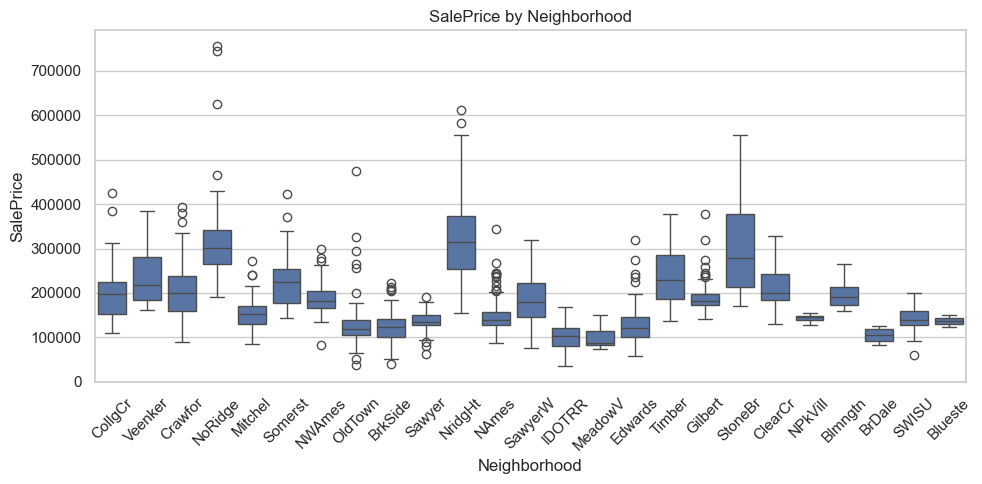

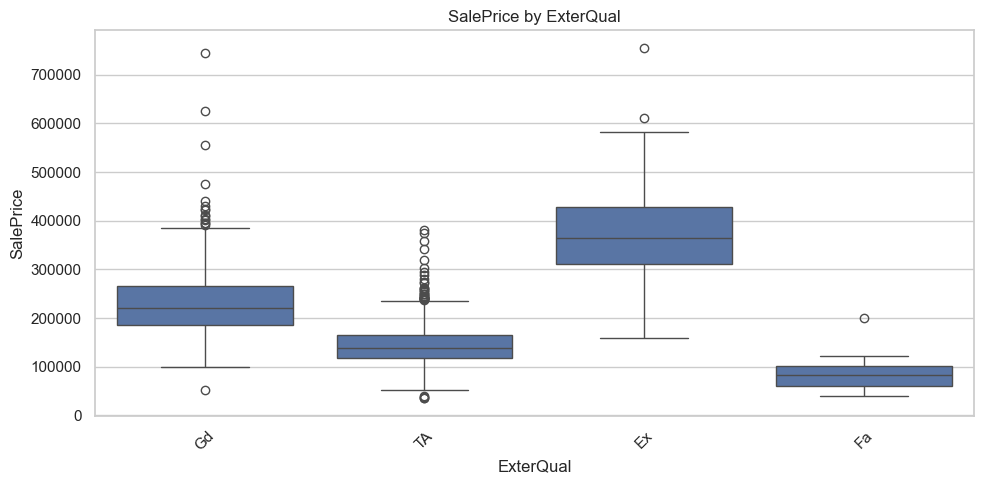

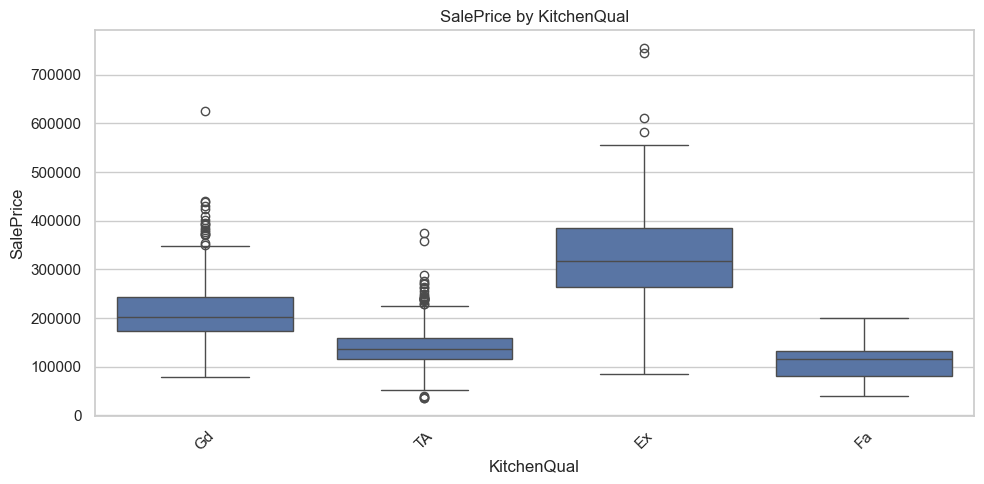

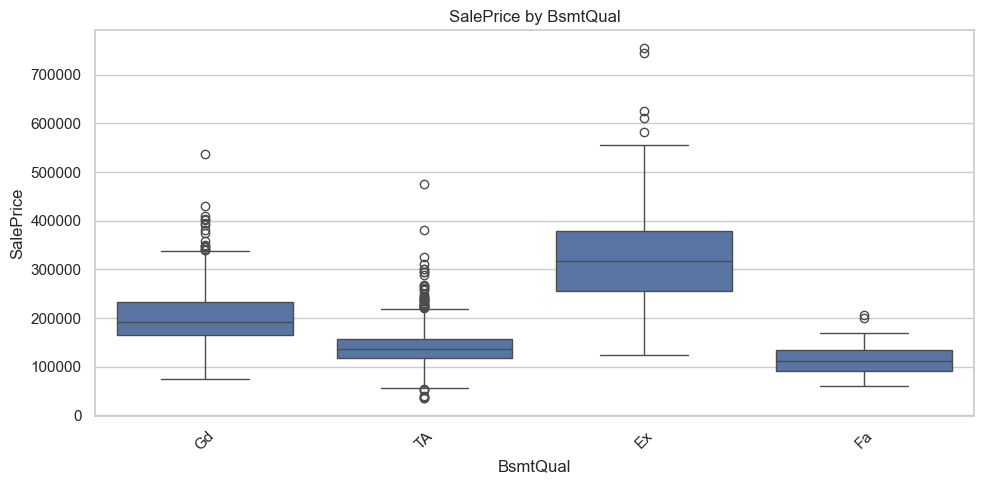

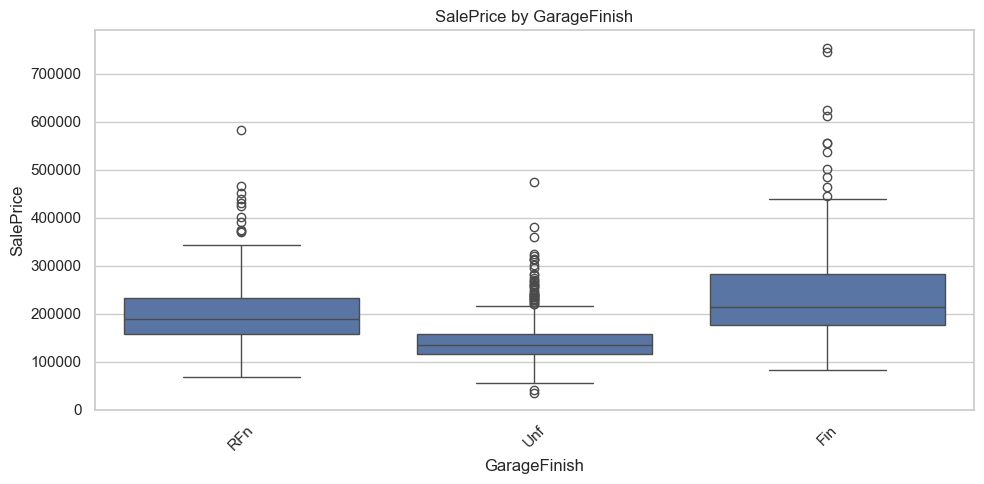

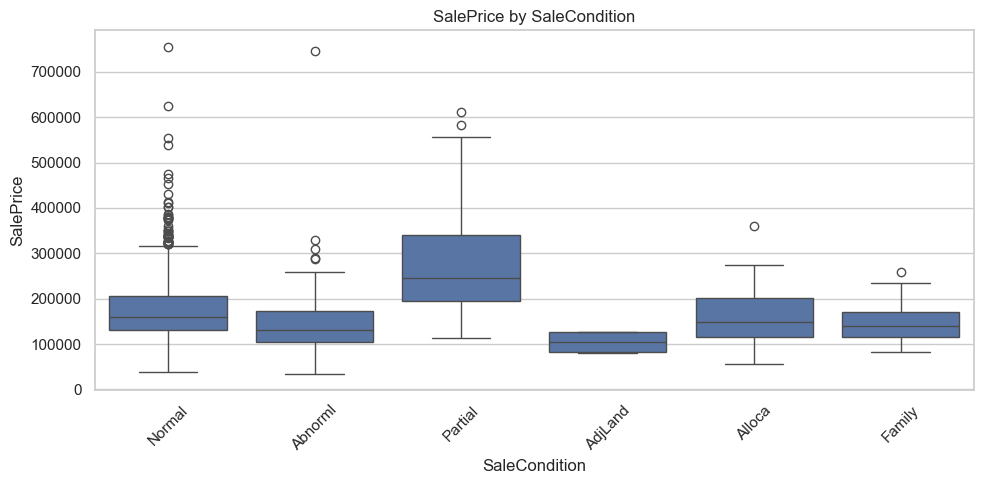

In [9]:
# Visualize important categorical features against SalePrice. Boxplots help us compare house prices across different categories. The line inside each box shows the median price. The box shows the middle range of prices. Dots outside the box can show possible outliers.

important_cats = [
    "Neighborhood",
    "ExterQual",
    "KitchenQual",
    "BsmtQual",
    "GarageFinish",
    "SaleCondition"
]

for col in important_cats:
    if col in df.columns:
        plt.figure(figsize=(10, 5))
        sns.boxplot(data=df, x=col, y="SalePrice")
        plt.xticks(rotation=45)
        plt.title(f"SalePrice by {col}")
        plt.tight_layout()
        plt.show()

In [10]:
# One-hot encode categorical columns. This turns text categories into 0/1 columns.

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("Original dataset shape:", df.shape)
print("Encoded dataset shape:", df_encoded.shape)

# Show first few rows of the encoded dataset
df_encoded.head()

Original dataset shape: (1460, 77)
Encoded dataset shape: (1460, 237)


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,False,True,False,False,False,True,False


In [11]:
# Final check after encoding

print("Missing values remaining:", df_encoded.isnull().sum().sum())
print("Number of columns after encoding:", df_encoded.shape[1])

df_encoded.info()

Missing values remaining: 0
Number of columns after encoding: 237
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 237 entries, Id to SaleCondition_Partial
dtypes: bool(199), float64(3), int64(35)
memory usage: 717.3 KB


In [12]:
# We save the encoded dataset for phase 3 without changing the original dataset. This file can be used later for model building, especially Ridge Regression.

df_encoded.to_csv("gold_housing_encoded_iffah.csv", index=False)

print("Saved file: gold_housing_encoded_iffah.csv")

Saved file: gold_housing_encoded_iffah.csv
